# Estudo Comparativo de Implementações do Quicksort

**Disciplina:** Projeto e Análise de Algoritmos (PAA)

**Professor:** Walisson Ferreira de Carvalho

**Instituição:** Pontifícia Universidade Católica de Minas Gerais (PUC Minas)

Este caderno apresenta a implementação das três versões do Quicksort exigidas no enunciado do Trabalho Prático 1, a determinação empírica do parâmetro M, a descrição das massas de teste e a análise dos resultados obtidos nos experimentos. Todos os resultados podem ser reproduzidos executando as células na ordem em que aparecem.

## Ambiente de execução

As células a seguir importam os módulos do projeto, configuram o limite de recursão do interpretador (necessário porque o Quicksort clássico atinge profundidade de recursão proporcional ao tamanho do vetor em seu pior caso) e definem os diretórios onde tabelas e figuras são gravadas.

In [1]:
import os
import sys
import platform

def localizar_raiz():
    candidato = os.getcwd()
    if os.path.basename(candidato) == "notebooks":
        return os.path.dirname(candidato)
    if os.path.isdir(os.path.join(candidato, "quicksort")):
        return candidato
    return candidato

RAIZ = localizar_raiz()
if RAIZ not in sys.path:
    sys.path.insert(0, RAIZ)

from quicksort.quicksort import (
    QuicksortRecursivo,
    QuicksortHibrido,
    QuicksortHibridoMedianaTres,
)
from quicksort.gerador_dados import gerar_massa
from quicksort.experimentos import (
    ajustar_limite_de_recursao,
    executar_comparativo,
    medir_execucao,
)

from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

ajustar_limite_de_recursao(20000)

RESULTADOS = os.path.join(RAIZ, "resultados")
FIGURAS = os.path.join(RESULTADOS, "figuras")
TABELAS = os.path.join(RESULTADOS, "tabelas")
os.makedirs(FIGURAS, exist_ok=True)
os.makedirs(TABELAS, exist_ok=True)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda v: "{:.6f}".format(v))

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("ggplot")

def salvar_figura(figura, nome):
    caminho = os.path.join(FIGURAS, nome)
    figura.savefig(caminho, dpi=150, bbox_inches="tight")
    print("Figura salva em:", caminho)

print("Raiz do projeto:", RAIZ)
print("Versão do Python:", sys.version.split()[0])
print("Plataforma:", platform.platform())
if sys.platform == "win32":
    # No Python 3.11, platform.platform() identifica o Windows 11 como
    # "Windows-10", porque a versão interna continua 10.0. O número de build
    # distingue os dois sistemas: builds a partir de 22000 são Windows 11.
    build = int(platform.win32_ver()[1].split(".")[-1])
    print("Sistema operacional: Windows {} (build {})".format(
        "11" if build >= 22000 else "10", build))
print("Processador:", platform.processor())

Raiz do projeto: C:\Users\prodr\repos\quicksort-compare
Versão do Python: 3.11.9
Plataforma: Windows-10-10.0.26200-SP0


## Algoritmos implementados

Foram implementadas três versões do Quicksort, todas com particionamento de Lomuto e pivô no último elemento do intervalo:

1. **Quicksort recursivo:** versão clássica, em que cada partição divide o vetor em duas partes e o processo se repete recursivamente sobre cada parte.
2. **Quicksort híbrido:** a recursão é interrompida para subvetores com menos de M elementos, que são ordenados com o algoritmo de ordenação por inserção. O valor de M é determinado empiricamente na seção seguinte.
3. **Quicksort híbrido com mediana de três:** versão anterior com a escolha do pivô pela mediana entre o primeiro, o central e o último elemento do intervalo, o que reduz a probabilidade de partições desbalanceadas.

Todos os algoritmos mantêm contadores de comparações e de trocas, atualizados durante a execução, e o tempo é medido com a função time.perf_counter, que utiliza o relógio da máquina. Na ordenação por inserção, cada deslocamento de um elemento para a direita é contabilizado como uma troca. Na mediana de três, as comparações e as trocas realizadas na escolha do pivô também são contabilizadas.

O particionamento de Lomuto com pivô no último elemento faz com que vetores já ordenados caracterizem o pior caso do Quicksort clássico e do híbrido, tema explorado na seção dedicada ao pior caso.

## Determinação empírica do parâmetro M

O enunciado pede que o valor de M seja determinado empiricamente. Para isso, o Quicksort híbrido foi executado sobre vetores aleatórios de 1000 elementos, com 100 repetições para cada candidato de M, e o valor escolhido foi o que apresentou o menor tempo médio de execução. Em seguida, a escolha foi confirmada com vetores de 10000 elementos e 30 repetições.

In [2]:
VALORES_M = [5, 8, 10, 12, 15, 20, 25, 30, 40, 50]
TAMANHO_M = 1000
REPETICOES_M = 100

dados_m = gerar_massa("aleatorio", TAMANHO_M, semente=42)
linhas_m = []
for m in VALORES_M:
    ordenador = QuicksortHibrido(m=m)
    res = medir_execucao(ordenador, dados_m, repeticoes=REPETICOES_M)
    linhas_m.append({
        "M": m,
        "tempo_medio_ms": res["tempo_medio"] * 1000,
        "comparacoes_media": res["comparacoes_media"],
        "trocas_media": res["trocas_media"],
    })
tabela_m = pd.DataFrame(linhas_m)
tabela_m.to_csv(os.path.join(TABELAS, "determinacao_m_1000.csv"), index=False)
MELHOR_M = int(tabela_m.loc[tabela_m["tempo_medio_ms"].idxmin(), "M"])
print(tabela_m.to_string(index=False))
print()
print("Menor tempo médio observado para M =", MELHOR_M)

 M  tempo_medio_ms  comparacoes_media  trocas_media
 5        6.070131       11974.000000   5795.000000
 8        5.847290       12088.000000   6045.000000
10        7.056709       12136.000000   6189.000000
12        6.955207       12256.000000   6431.000000
15        8.698462       12460.000000   6759.000000
20        8.457828       12771.000000   7283.000000
25       12.082982       13312.000000   7967.000000
30       12.536520       14008.000000   8871.000000
40       12.760067       15217.000000  10295.000000
50       15.261388       16481.000000  11727.000000

Menor tempo médio observado para M = 8


Figura salva em: C:\Users\prodr\repos\quicksort-compare\resultados\figuras\determinacao_m.png


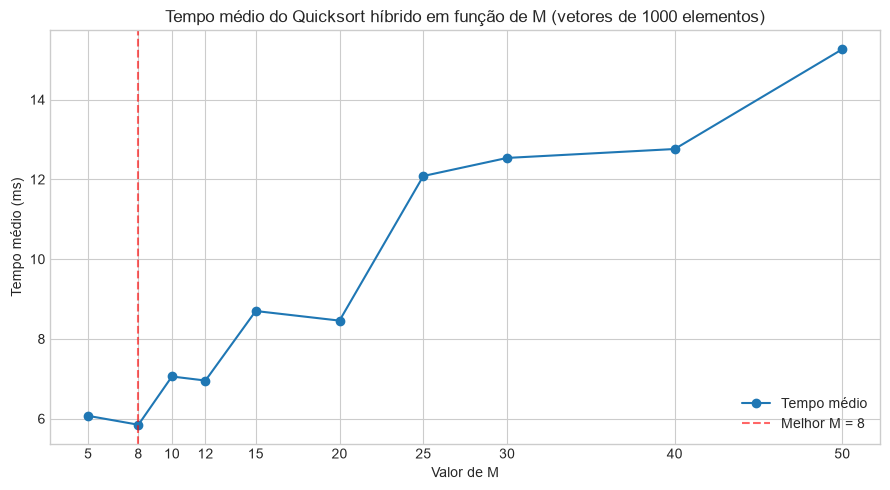

In [3]:
figura, eixo = plt.subplots(figsize=(9, 5))
eixo.plot(tabela_m["M"], tabela_m["tempo_medio_ms"], marker="o", label="Tempo médio")
eixo.axvline(MELHOR_M, color="red", linestyle="--", alpha=0.6,
             label="Melhor M = {}".format(MELHOR_M))
eixo.set_xlabel("Valor de M")
eixo.set_ylabel("Tempo médio (ms)")
eixo.set_title("Tempo médio do Quicksort híbrido em função de M (vetores de 1000 elementos)")
eixo.set_xticks(VALORES_M)
eixo.legend()
plt.tight_layout()
salvar_figura(figura, "determinacao_m.png")
plt.show()

In [4]:
TAMANHO_M2 = 10000
REPETICOES_M2 = 30

dados_m2 = gerar_massa("aleatorio", TAMANHO_M2, semente=123)
linhas_m2 = []
for m in VALORES_M:
    ordenador = QuicksortHibrido(m=m)
    res = medir_execucao(ordenador, dados_m2, repeticoes=REPETICOES_M2)
    linhas_m2.append({
        "M": m,
        "tempo_medio_ms": res["tempo_medio"] * 1000,
        "comparacoes_media": res["comparacoes_media"],
        "trocas_media": res["trocas_media"],
    })
tabela_m2 = pd.DataFrame(linhas_m2)
tabela_m2.to_csv(os.path.join(TABELAS, "determinacao_m_10000.csv"), index=False)
melhor_m2 = int(tabela_m2.loc[tabela_m2["tempo_medio_ms"].idxmin(), "M"])
print(tabela_m2.to_string(index=False))
print()
print("Menor tempo médio observado para M =", melhor_m2, "com vetores de 10000 elementos")

 M  tempo_medio_ms  comparacoes_media  trocas_media
 5      271.850240      146151.000000  71588.000000
 8      301.239057      146769.000000  74046.000000
10      115.399633      147456.000000  75857.000000
12       77.515557      148733.000000  78348.000000
15      103.632943      150515.000000  81479.000000
20       93.472020      154651.000000  87589.000000
25      109.697663      159841.000000  94451.000000
30      123.884110      164135.000000 100162.000000
40      125.515510      177405.000000 116104.000000
50      131.127227      190107.000000 130925.000000

Menor tempo médio observado para M = 12 com vetores de 10000 elementos


## Massas de teste

Foram utilizadas quatro massas de teste, conforme o enunciado:

1. **aleatorio:** valores sorteados uniformemente no intervalo de 0 a 999999;
2. **ordenado:** valores em ordem crescente;
3. **inverso:** valores em ordem decrescente;
4. **repetidos:** valores sorteados no intervalo de 0 a 99, o que produz muitos elementos repetidos.

As massas são geradas com semente fixa, portanto todas as versões e todas as repetições utilizam exatamente os mesmos dados. Para as massas ordenada e inversa, que induzem o pior caso das versões com pivô no último elemento, foram utilizados tamanhos menores, tanto pelo custo computacional O(n²) quanto pela profundidade de recursão proporcional a n imposta pelo interpretador Python.

In [5]:
TAMANHOS = {
    "aleatorio": [1000, 10000, 50000],
    "ordenado": [1000, 2000, 4000],
    "inverso": [1000, 2000, 4000],
    "repetidos": [1000, 10000, 50000],
}

massas = {}
for nome, tamanhos in TAMANHOS.items():
    massas[nome] = {}
    for tamanho in tamanhos:
        massas[nome][tamanho] = gerar_massa(nome, tamanho, semente=42)

for nome, dados_por_tamanho in massas.items():
    for tamanho in sorted(dados_por_tamanho):
        dados = dados_por_tamanho[tamanho]
        unicos = len(set(dados))
        print("Massa {:10s} tamanho {:6d} elementos únicos {:7d}".format(nome, tamanho, unicos))

Massa aleatorio  tamanho   1000 elementos únicos    1000


Massa aleatorio  tamanho  10000 elementos únicos    9959
Massa aleatorio  tamanho  50000 elementos únicos   48779
Massa ordenado   tamanho   1000 elementos únicos    1000
Massa ordenado   tamanho   2000 elementos únicos    2000
Massa ordenado   tamanho   4000 elementos únicos    4000
Massa inverso    tamanho   1000 elementos únicos    1000
Massa inverso    tamanho   2000 elementos únicos    2000
Massa inverso    tamanho   4000 elementos únicos    4000
Massa repetidos  tamanho   1000 elementos únicos     100
Massa repetidos  tamanho  10000 elementos únicos     100
Massa repetidos  tamanho  50000 elementos únicos     100


## Versões utilizadas nos experimentos

As três versões foram configuradas com M = 8, valor determinado empiricamente na seção anterior, e executadas sobre as mesmas massas de dados. O valor é fixado no código, pois a determinação de M depende de medições de tempo que variam entre execuções; assim, uma reexecução do caderno não altera as versões comparadas.

In [6]:
# M é fixado em 8, o valor adotado no relatório. MELHOR_M, calculado na
# determinação de M, depende de medições de tempo e pode mudar entre
# execuções; fixar M mantém as versões comparadas iguais às do relatório.
M = 8
if MELHOR_M != M:
    print("Atenção: nesta execução, o menor tempo médio foi observado para M =", MELHOR_M)
versoes = [
    QuicksortRecursivo(),
    QuicksortHibrido(m=M),
    QuicksortHibridoMedianaTres(m=M),
]
for versao in versoes:
    print(versao.nome)
print()
print("Valor de M utilizado:", M)

Quicksort recursivo
Quicksort híbrido (M = 8)
Quicksort híbrido com mediana de três (M = 8)

Valor de M utilizado: 8


## Experimento comparativo

Para cada massa e cada tamanho, as três versões foram executadas sobre cópias idênticas dos dados, com 5 repetições para as massas aleatória e repetidos e 3 repetições para as massas ordenada e inversa, em razão do maior custo computacional destas últimas. Para cada execução foram registrados o tempo, o número de comparações e o número de trocas, apresentados a seguir como valores médios.

In [7]:
def executar_massa(nome, repeticoes):
    linhas = []
    for tamanho in sorted(massas[nome]):
        dados = massas[nome][tamanho]
        resultados = executar_comparativo(versoes, {nome: dados}, repeticoes=repeticoes)
        for nome_versao, res in resultados[nome].items():
            linhas.append({
                "tamanho": tamanho,
                "versao": nome_versao,
                "tempo_medio_s": res["tempo_medio"],
                "comparacoes_media": res["comparacoes_media"],
                "trocas_media": res["trocas_media"],
            })
    return pd.DataFrame(linhas)


def apresentar_massa(nome, repeticoes):
    df = executar_massa(nome, repeticoes)
    print("Massa:", nome, "| Número de repetições:", repeticoes)
    display(df)
    df.to_csv(os.path.join(TABELAS, "comparativo_{}.csv".format(nome)), index=False)
    return df


def grafico_massa(nome, df):
    figura, eixos = plt.subplots(1, 3, figsize=(16, 4.5))
    configuracoes = [
        ("tempo_medio_s", "Tempo médio (s)", "log"),
        ("comparacoes_media", "Comparações médias", "log"),
        ("trocas_media", "Trocas médias", "linear"),
    ]
    for eixo, (coluna, rotulo, escala) in zip(eixos, configuracoes):
        for nome_versao in df["versao"].unique():
            dados = df[df["versao"] == nome_versao]
            eixo.plot(dados["tamanho"], dados[coluna], marker="o", label=nome_versao)
        eixo.set_xscale("log")
        eixo.set_yscale(escala)
        eixo.set_xlabel("Tamanho do vetor")
        eixo.set_ylabel(rotulo)
        eixo.set_title(rotulo)
        eixo.legend(fontsize=7)
    figura.suptitle("Massa {}".format(nome))
    plt.tight_layout()
    salvar_figura(figura, "comparativo_{}.png".format(nome))
    plt.show()

Massa: aleatorio | Número de repetições: 5


,tamanho,versao,tempo_medio_s,comparacoes_media,trocas_media
0,1000,Quicksort recursivo,0.010467,11972.000000,5715.000000
1,1000,Quicksort híbrido (M = 8),0.006295,12088.000000,6045.000000
2,1000,Quicksort híbrido com mediana de três (M = 8),0.004558,10320.000000,5263.000000
3,10000,Quicksort recursivo,0.062948,154959.000000,70735.000000
4,10000,Quicksort híbrido (M = 8),0.075114,155673.000000,73897.000000
5,10000,Quicksort híbrido com mediana de três (M = 8),0.106018,137460.000000,67641.000000
6,50000,Quicksort recursivo,0.495921,927813.000000,456100.000000
7,50000,Quicksort híbrido (M = 8),0.474180,931395.000000,472384.000000
8,50000,Quicksort híbrido com mediana de três (M = 8),0.444834,832234.000000,408948.000000


Figura salva em: C:\Users\prodr\repos\quicksort-compare\resultados\figuras\comparativo_aleatorio.png


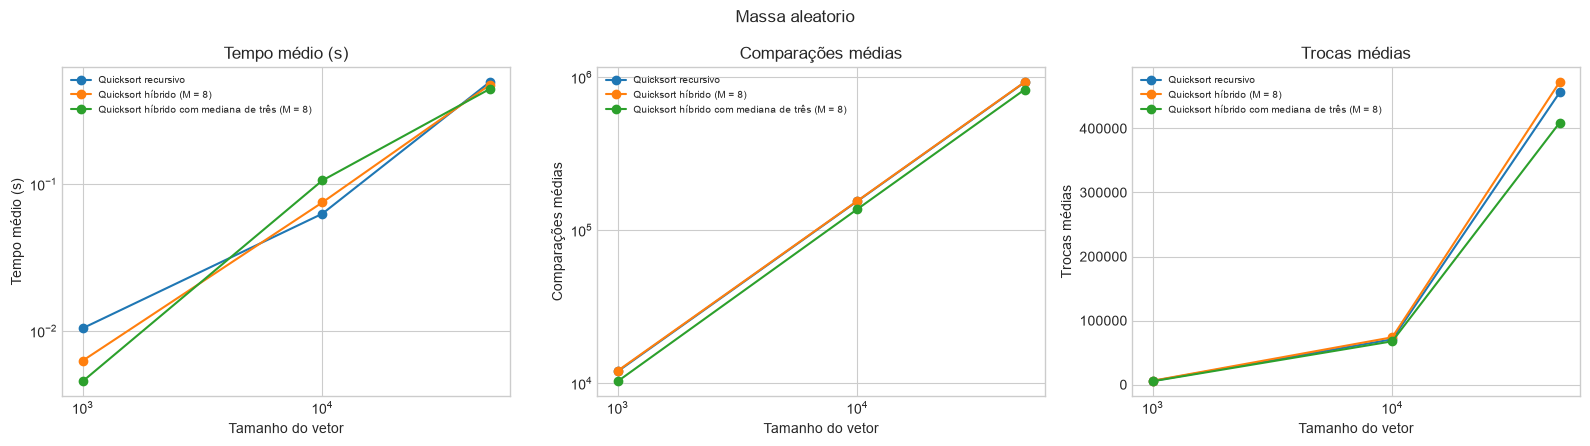

In [8]:
df_aleatorio = apresentar_massa("aleatorio", 5)
grafico_massa("aleatorio", df_aleatorio)

Massa: ordenado | Número de repetições: 3


,tamanho,versao,tempo_medio_s,comparacoes_media,trocas_media
0,1000,Quicksort recursivo,0.298949,499500.000000,0.000000
1,1000,Quicksort híbrido (M = 8),0.284515,499485.000000,0.000000
2,1000,Quicksort híbrido com mediana de três (M = 8),0.001932,7879.000000,254.000000
3,2000,Quicksort recursivo,1.634435,1999000.000000,0.000000
4,2000,Quicksort híbrido (M = 8),2.490269,1998985.000000,0.000000
5,2000,Quicksort híbrido com mediana de três (M = 8),0.010473,17752.000000,510.000000
6,4000,Quicksort recursivo,10.850065,7998000.000000,0.000000
7,4000,Quicksort híbrido (M = 8),8.647366,7997985.000000,0.000000
8,4000,Quicksort híbrido com mediana de três (M = 8),0.022818,39497.000000,1022.000000


Figura salva em: C:\Users\prodr\repos\quicksort-compare\resultados\figuras\comparativo_ordenado.png


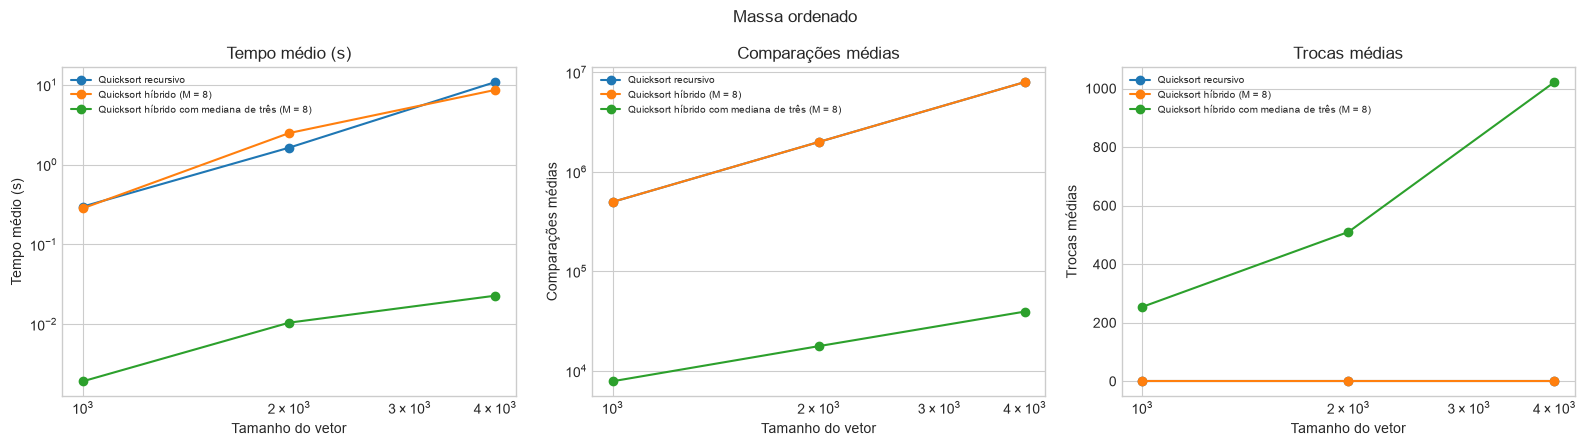

In [9]:
df_ordenado = apresentar_massa("ordenado", 3)
grafico_massa("ordenado", df_ordenado)

Massa: inverso | Número de repetições: 3


,tamanho,versao,tempo_medio_s,comparacoes_media,trocas_media
0,1000,Quicksort recursivo,0.140021,499500.000000,500.000000
1,1000,Quicksort híbrido (M = 8),0.178652,499495.000000,512.000000
2,1000,Quicksort híbrido com mediana de três (M = 8),0.008513,15373.000000,6792.000000
3,2000,Quicksort recursivo,0.588174,1999000.000000,1000.000000
4,2000,Quicksort híbrido (M = 8),0.728108,1998995.000000,1012.000000
5,2000,Quicksort híbrido com mediana de três (M = 8),0.013205,35205.000000,15324.000000
6,4000,Quicksort recursivo,2.717542,7998000.000000,2000.000000
7,4000,Quicksort híbrido (M = 8),4.211748,7997995.000000,2012.000000
8,4000,Quicksort híbrido com mediana de três (M = 8),0.036949,79969.000000,34426.000000


Figura salva em: C:\Users\prodr\repos\quicksort-compare\resultados\figuras\comparativo_inverso.png


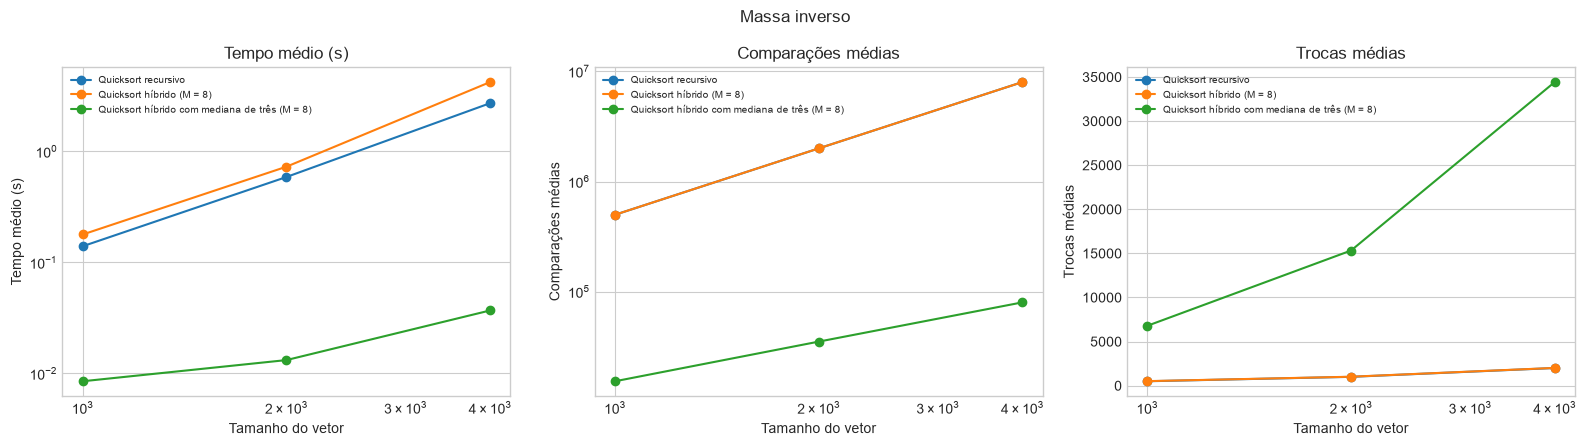

In [10]:
df_inverso = apresentar_massa("inverso", 3)
grafico_massa("inverso", df_inverso)

Massa: repetidos | Número de repetições: 5


,tamanho,versao,tempo_medio_s,comparacoes_media,trocas_media
0,1000,Quicksort recursivo,0.005699,12474.000000,3795.000000
1,1000,Quicksort híbrido (M = 8),0.006583,11177.000000,3795.000000
2,1000,Quicksort híbrido com mediana de três (M = 8),0.004821,11544.000000,4481.000000
3,10000,Quicksort recursivo,0.354130,584998.000000,48401.000000
4,10000,Quicksort híbrido (M = 8),0.337862,583498.000000,48401.000000
5,10000,Quicksort híbrido com mediana de três (M = 8),0.376752,598536.000000,49858.000000
6,50000,Quicksort recursivo,8.991338,12929058.000000,146354.000000
7,50000,Quicksort híbrido (M = 8),8.663099,12927558.000000,146354.000000
8,50000,Quicksort híbrido com mediana de três (M = 8),9.152913,13042342.000000,235978.000000


Figura salva em: C:\Users\prodr\repos\quicksort-compare\resultados\figuras\comparativo_repetidos.png


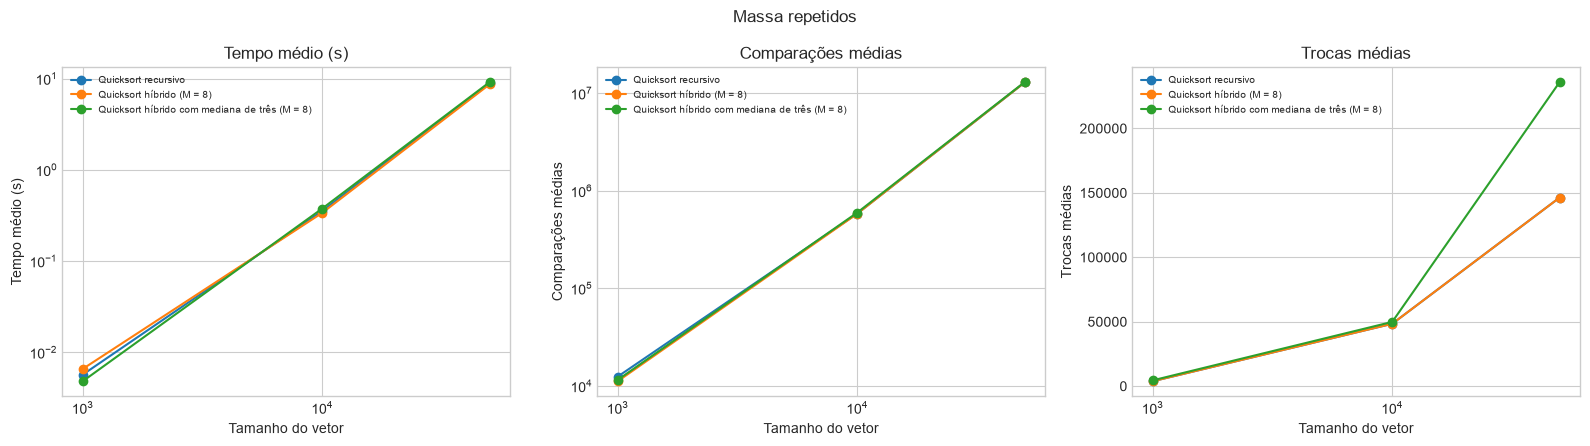

In [11]:
df_repetidos = apresentar_massa("repetidos", 5)
grafico_massa("repetidos", df_repetidos)

## Pior caso forçado

O particionamento de Lomuto com pivô no último elemento faz com que um vetor já ordenado seja o pior caso do Quicksort recursivo e do híbrido: a cada partição o pivô é o maior elemento, um dos subvetores fica vazio e a profundidade de recursão fica proporcional a n, resultando em custo quadrático. Para evidenciar esse comportamento, as três versões foram executadas sobre vetores já ordenados de tamanhos 1000, 2000, 4000 e 8000, com 2 repetições, e as razões entre os resultados de tamanhos consecutivos foram calculadas.

In [12]:
TAMANHOS_PIOR_CASO = [1000, 2000, 4000, 8000]
REPETICOES_PIOR_CASO = 2

linhas_pc = []
for tamanho in TAMANHOS_PIOR_CASO:
    dados = gerar_massa("ordenado", tamanho, semente=42)
    resultados = executar_comparativo(versoes, {"ordenado": dados}, repeticoes=REPETICOES_PIOR_CASO)
    for nome_versao, res in resultados["ordenado"].items():
        linhas_pc.append({
            "tamanho": tamanho,
            "versao": nome_versao,
            "tempo_medio_s": res["tempo_medio"],
            "comparacoes_media": res["comparacoes_media"],
            "trocas_media": res["trocas_media"],
        })

tabela_pc = pd.DataFrame(linhas_pc)
print(tabela_pc.to_string(index=False))
tabela_pc.to_csv(os.path.join(TABELAS, "pior_caso.csv"), index=False)

 tamanho                                        versao  tempo_medio_s  comparacoes_media  trocas_media
    1000                           Quicksort recursivo       0.381476      499500.000000      0.000000
    1000                     Quicksort híbrido (M = 8)       0.302870      499485.000000      0.000000
    1000 Quicksort híbrido com mediana de três (M = 8)       0.001981        7879.000000    254.000000
    2000                           Quicksort recursivo       1.133994     1999000.000000      0.000000
    2000                     Quicksort híbrido (M = 8)       1.200227     1998985.000000      0.000000
    2000 Quicksort híbrido com mediana de três (M = 8)       0.005877       17752.000000    510.000000
    4000                           Quicksort recursivo       4.813868     7998000.000000      0.000000
    4000                     Quicksort híbrido (M = 8)       6.542255     7997985.000000      0.000000
    4000 Quicksort híbrido com mediana de três (M = 8)       0.016328    

In [13]:
def razoes(df, coluna):
    linhas = []
    for nome_versao in df["versao"].unique():
        sub = df[df["versao"] == nome_versao].sort_values("tamanho")
        for i in range(1, len(sub)):
            anterior = sub.iloc[i - 1][coluna]
            atual = sub.iloc[i][coluna]
            linhas.append({
                "versao": nome_versao,
                "faixa": "{} para {}".format(int(sub.iloc[i - 1]["tamanho"]), int(sub.iloc[i]["tamanho"])),
                "razao": (atual / anterior) if anterior else float("nan"),
            })
    return pd.DataFrame(linhas)

print("Razão entre os tempos médios ao dobrar o tamanho do vetor")
print(razoes(tabela_pc, "tempo_medio_s").to_string(index=False))
print()
print("Razão entre as comparações médias ao dobrar o tamanho do vetor")
print(razoes(tabela_pc, "comparacoes_media").to_string(index=False))

Razão entre os tempos médios ao dobrar o tamanho do vetor
                                       versao          faixa    razao
                          Quicksort recursivo 1000 para 2000 2.972644
                          Quicksort recursivo 2000 para 4000 4.245057
                          Quicksort recursivo 4000 para 8000 4.443501
                    Quicksort híbrido (M = 8) 1000 para 2000 3.962847
                    Quicksort híbrido (M = 8) 2000 para 4000 5.450847
                    Quicksort híbrido (M = 8) 4000 para 8000 3.997425
Quicksort híbrido com mediana de três (M = 8) 1000 para 2000 2.966631
Quicksort híbrido com mediana de três (M = 8) 2000 para 4000 2.778426
Quicksort híbrido com mediana de três (M = 8) 4000 para 8000 2.107229

Razão entre as comparações médias ao dobrar o tamanho do vetor
                                       versao          faixa    razao
                          Quicksort recursivo 1000 para 2000 4.002002
                          Quicksort re

Figura salva em: C:\Users\prodr\repos\quicksort-compare\resultados\figuras\pior_caso.png


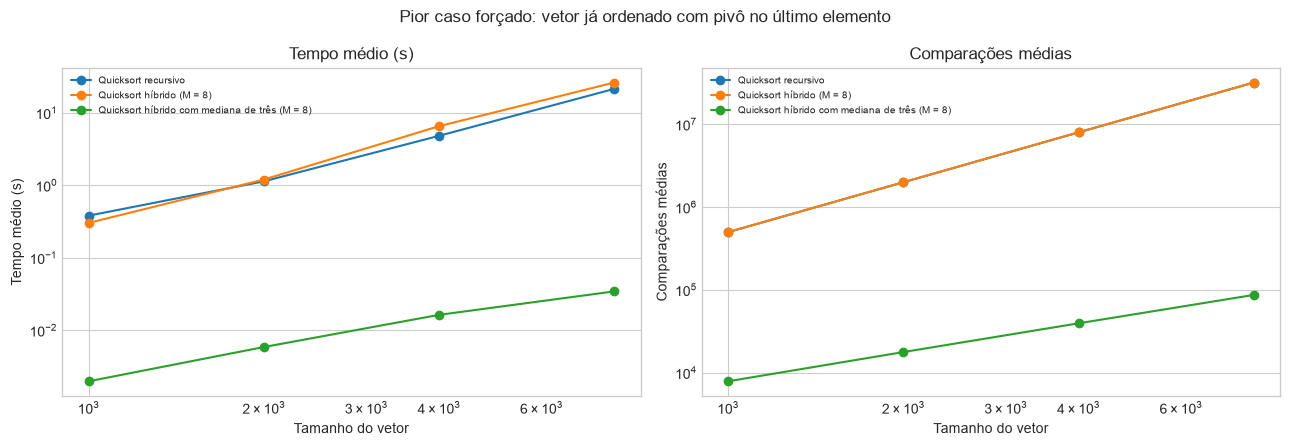

In [14]:
figura, eixos = plt.subplots(1, 2, figsize=(13, 4.5))
configuracoes = [
    ("tempo_medio_s", "Tempo médio (s)"),
    ("comparacoes_media", "Comparações médias"),
]
for eixo, (coluna, rotulo) in zip(eixos, configuracoes):
    for nome_versao in tabela_pc["versao"].unique():
        dados = tabela_pc[tabela_pc["versao"] == nome_versao]
        eixo.plot(dados["tamanho"], dados[coluna], marker="o", label=nome_versao)
    eixo.set_xscale("log")
    eixo.set_yscale("log")
    eixo.set_xlabel("Tamanho do vetor")
    eixo.set_ylabel(rotulo)
    eixo.set_title(rotulo)
    eixo.legend(fontsize=7)
figura.suptitle("Pior caso forçado: vetor já ordenado com pivô no último elemento")
plt.tight_layout()
salvar_figura(figura, "pior_caso.png")
plt.show()

## Análise dos resultados

### Determinação do parâmetro M

Na determinação empírica de M, o Quicksort híbrido foi executado sobre vetores aleatórios de 1000 elementos, com 100 repetições para cada candidato. O menor tempo médio foi observado para M igual a 8, com aproximadamente 5,85 ms. Valores muito pequenos de M mantêm a maior parte do custo das chamadas recursivas, enquanto valores grandes aumentam o trabalho da ordenação por inserção, que não aproveita tão bem a ordenação parcial promovida pelas partições. O número de comparações cresce de forma monotônica com M, de 11974 comparações para M igual a 5 até 16481 para M igual a 50, o que confirma que a escolha de M envolve um equilíbrio entre o custo das chamadas recursivas e o custo da ordenação por inserção.

Na confirmação com vetores de 10000 elementos, o mínimo observado foi M igual a 12, porém com tempos próximos para valores vizinhos de M e números de comparações praticamente iguais (146769 para M igual a 8 e 148733 para M igual a 12). A diferença em relação ao experimento com 1000 elementos se deve à variabilidade das medições de tempo. O valor adotado nos demais experimentos foi M igual a 8, coerente com a faixa tipicamente recomendada na literatura, que situa o limiar entre 5 e 20 elementos.

### Massa aleatória

Nas massas aleatórias, as três versões apresentam comportamento compatível com a complexidade O(n log n). Para 50000 elementos, os tempos médios foram 0,496 s (recursivo), 0,474 s (híbrido) e 0,445 s (mediana de três), com 927813, 931395 e 832234 comparações, respectivamente. A mediana de três realiza cerca de 10% menos comparações porque o pivô escolhido tende a dividir o vetor de forma mais equilibrada, e essa redução compensa as três comparações adicionais realizadas na escolha do pivô. Para tamanhos pequenos, as diferenças de tempo ficam dentro da variabilidade das medições.

### Massa ordenada e inversa

Essas massas caracterizam o pior caso das versões com pivô no último elemento. O Quicksort recursivo e o híbrido realizam exatamente n(n - 1)/2 comparações, com 499500 comparações para 1000 elementos, 1999000 para 2000 e 7998000 para 4000, o que confirma o comportamento quadrático previsto pela teoria. Na massa ordenada o número de trocas é zero, pois o pivô, sendo sempre o maior elemento, já se encontra em sua posição final; na massa inversa o número de trocas é n - 1, uma troca por partição. Em ambos os casos, os tempos crescem aproximadamente quatro vezes a cada duplicação do tamanho.

A mediana de três mantém o comportamento O(n log n): para 4000 elementos ordenados, o tempo médio foi 0,023 s contra 10,85 s do Quicksort recursivo, cerca de 476 vezes mais rápido, com 39497 comparações contra 7998000. A escolha do pivô pela mediana elimina as partições desbalanceadas, pois o pivô passa a ser o elemento central do intervalo.

### Massa com muitos repetidos

A massa com muitos repetidos revelou a fragilidade das versões com particionamento de Lomuto diante de chaves duplicadas. Com chaves sorteadas entre 0 e 99, a ordenação de 50000 elementos exigiu cerca de 12,9 milhões de comparações e 9,0 s no Quicksort recursivo, contra cerca de 0,93 milhão de comparações e 0,50 s na massa aleatória. O particionamento de Lomuto com comparação menor ou igual move todas as chaves iguais ao pivô para um único lado da partição; quando um subvetor fica formado por chaves iguais, ele é reduzido de um elemento por partição, comportamento análogo ao pior caso para cada grupo de chaves repetidas. A mediana de três não elimina esse efeito e ainda acrescenta o custo da escolha do pivô, com 9,15 s e 13,0 milhões de comparações. Esse resultado reforça a recomendação de esquemas de particionamento que distribuem as chaves iguais entre os dois lados, como a variante de Hoare.

### Pior caso forçado

No experimento dedicado ao pior caso, com vetores já ordenados de 1000 a 8000 elementos e 2 repetições, o Quicksort recursivo apresentou razão de comparações de exatamente 4,00 entre tamanhos consecutivos, o que caracteriza o custo quadrático, e as razões de tempo ficaram próximas de 4 (2,97, 4,24 e 4,44), com a variabilidade esperada de medição. A mediana de três apresentou razões de comparações próximas de 2,25 e razões de tempo entre 2,1 e 3,0, compatíveis com O(n log n), e foi cerca de 622 vezes mais rápida que o recursivo no vetor de 8000 elementos, com 0,034 s contra 21,39 s. Os tamanhos desse experimento foram limitados a 8000 elementos pelo custo quadrático e pela profundidade de recursão, conforme justificado na metodologia.

## Conclusão

Este trabalho implementou e comparou três versões do Quicksort: a versão recursiva clássica, a versão híbrida com ordenação por inserção para subvetores abaixo de um limiar M e a versão híbrida com escolha do pivô pela mediana de três. O limiar M foi determinado empiricamente como 8, a partir de experimentos com vetores de 1000 elementos, conforme sugerido no enunciado.

Os experimentos confirmaram, com dados quantitativos, as previsões da teoria. Nas massas aleatórias, as três versões apresentam custo O(n log n), com ligeira vantagem da mediana de três. Nas massas ordenada e inversa, o Quicksort recursivo e o híbrido degradam para o custo quadrático, com exatamente n(n - 1)/2 comparações, enquanto a mediana de três mantém o custo O(n log n) e se mostrou centenas de vezes mais rápida. A massa com muitos elementos repetidos evidenciou a fragilidade do particionamento de Lomuto diante de chaves duplicadas, que concentram as chaves iguais em um único lado da partição.

Conclui-se que a escolha do pivô é o fator mais decisivo para a robustez do Quicksort: a mediana de três eliminou o pior caso das entradas ordenadas, ao custo de um pequeno overhead, enquanto a interrupção com ordenação por inserção, embora benéfica em termos de constantes, não altera a complexidade do algoritmo. Os resultados obtidos servem de base para o relatório final do trabalho, a ser redigido em LaTeX.

## Referências

CORMEN, Thomas H.; LEISERSON, Charles E.; RIVEST, Ronald L.; STEIN, Clifford. **Algoritmos: teoria e prática.** 3. ed. Rio de Janeiro: Elsevier, 2012.

SEDGEWICK, Robert; WAYNE, Kevin. **Algorithms.** 4. ed. Boston: Addison-Wesley, 2011.

ZIVIANI, Nivio. **Projeto de algoritmos: com implementações em Pascal e C.** 3. ed. Porto Alegre: Cengage Learning, 2018.